## Day 3 — Backpropagation, Gradient Descent & Optimizers  

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [18]:
df = pd.read_csv('/content/kc_house_data.csv')

In [20]:
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [21]:
df.drop(columns=['id','date'], inplace=True)

In [28]:
numeric_cols = df.select_dtypes(include='number').columns


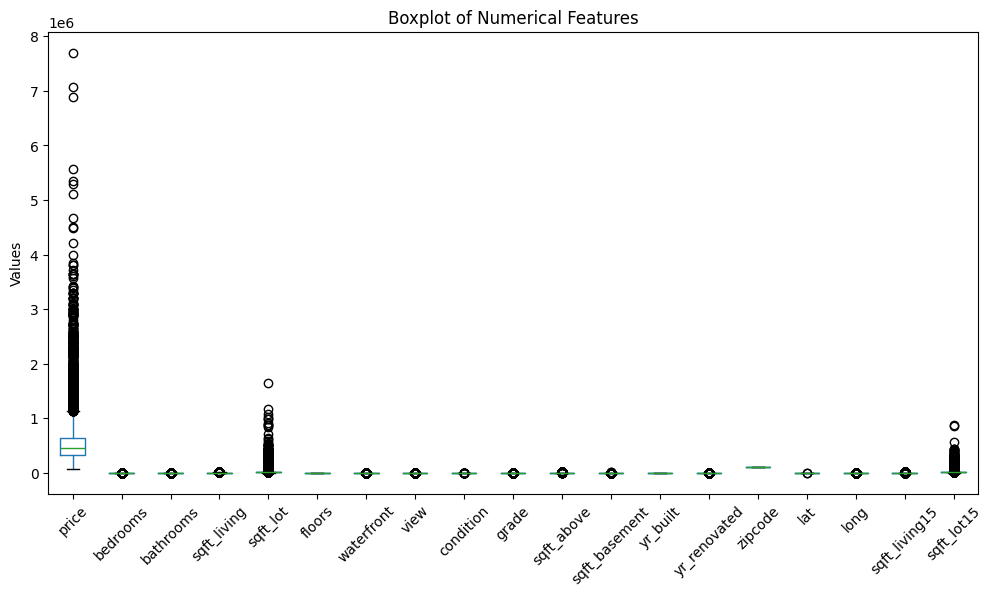

In [29]:
# Select numerical columns


plt.figure(figsize=(12, 6))

df[numeric_cols].boxplot()

plt.title("Boxplot of Numerical Features")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.grid(False)

plt.show()

In [30]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## Exploratory Data Analysis: Numerical Features

The dataset contains **21,613 observations and 21 columns**. The numerical features were examined using descriptive statistics and boxplots to understand their distributions and identify potential outliers.

### Descriptive Statistics

The target variable, `price`, has a mean of approximately **$540,088** and a median of **$450,000**. The difference between the mean and median suggests that the price distribution is right-skewed.

The main property features show the following patterns:

- `bedrooms` has a mean of **3.37**, with values ranging from 0 to 33.
- `bathrooms` has a mean of **2.11**, ranging from 0 to 8.
- `sqft_living` has a mean of approximately **2,080 sq ft**, with a maximum of 13,540 sq ft.
- `sqft_lot` is highly variable, with a mean of approximately **15,107 sq ft** and a maximum of **1,651,359 sq ft**.
- `yr_built` ranges from **1900 to 2015**, while `yr_renovated` contains many zero values, indicating properties that were not renovated.
- `sqft_living15` and `sqft_lot15` also show substantial variation.

### Outlier Analysis

The boxplot shows several potential outliers, particularly in:

- `price`
- `sqft_living`
- `sqft_lot`
- `sqft_living15`
- `sqft_lot15`

These observations are not automatically removed because they may represent genuine large or expensive properties rather than errors.

The large differences in scale between features also show why **feature scaling will be important before training the neural network**.

Overall, the dataset contains sufficient observations and useful numerical features for building a regression model to predict house prices.

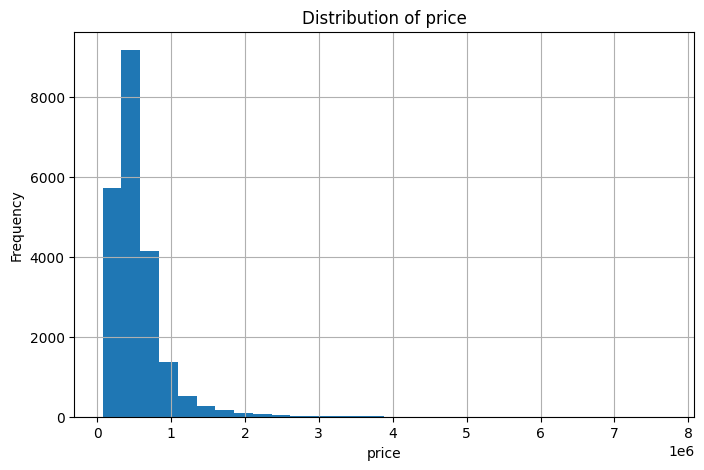

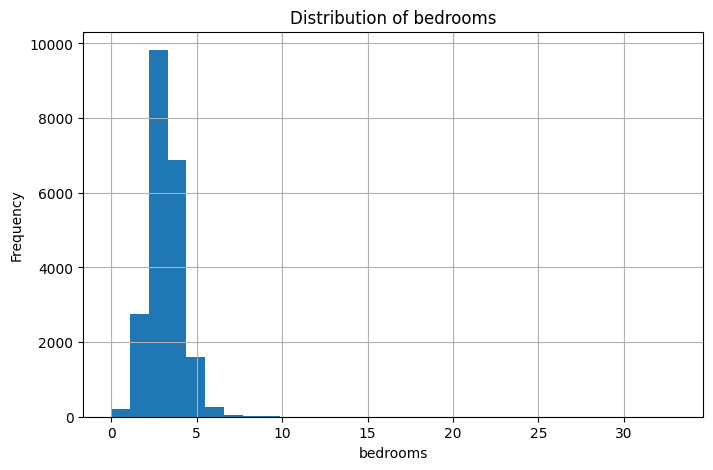

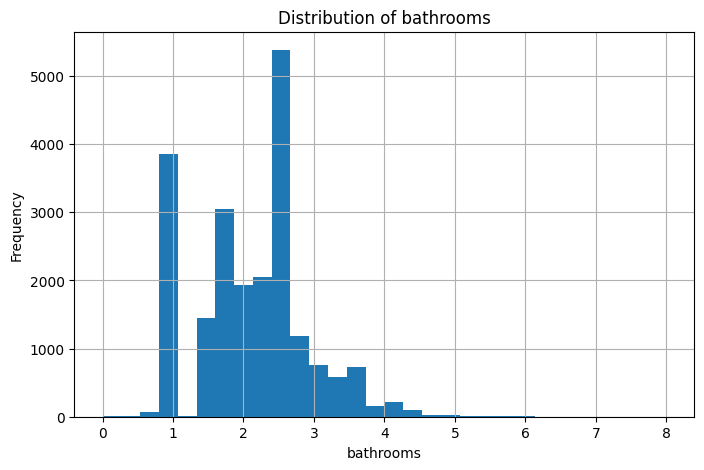

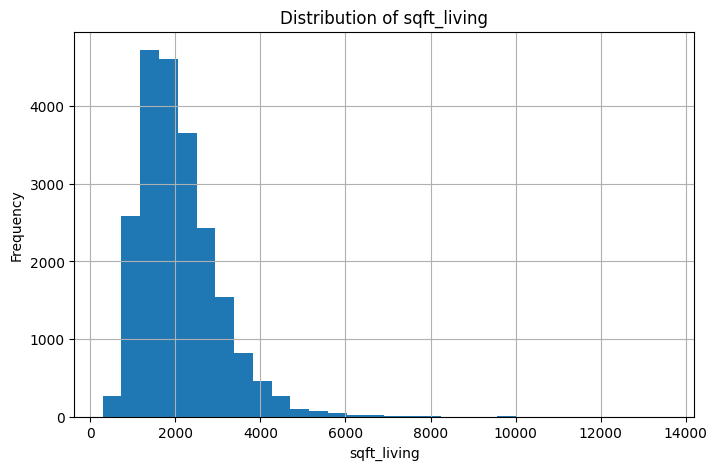

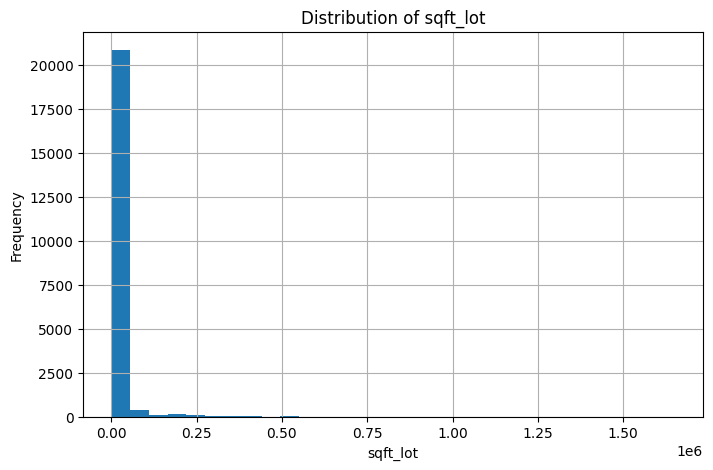

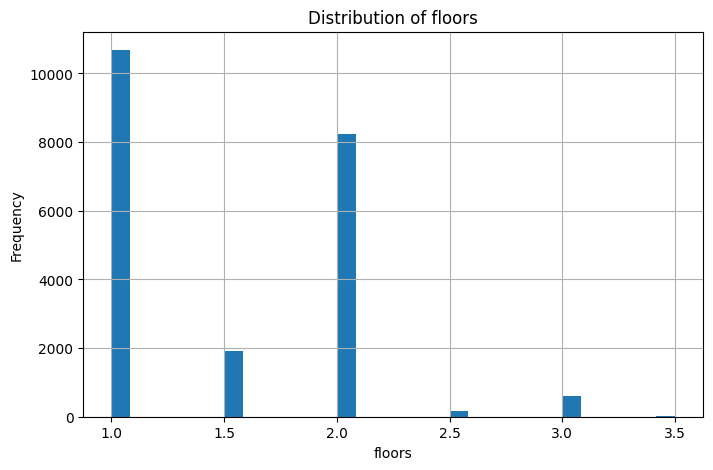

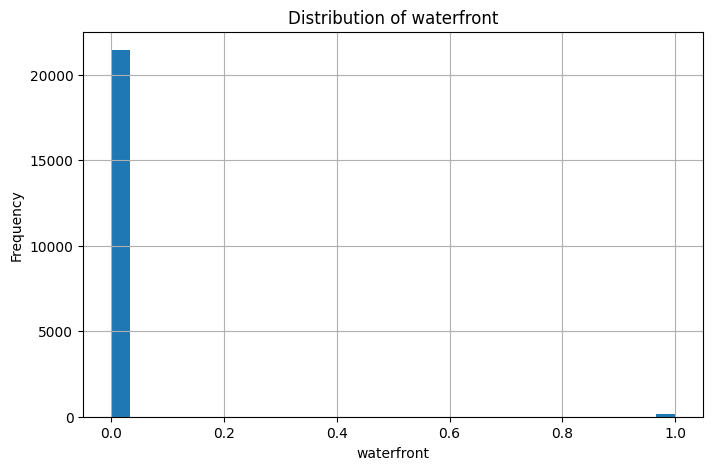

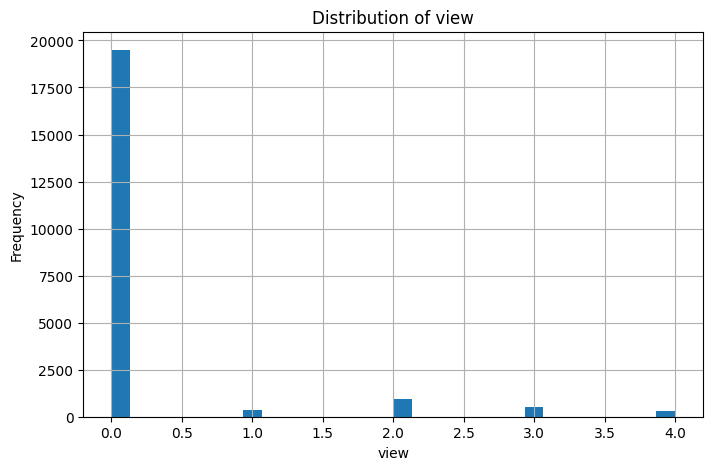

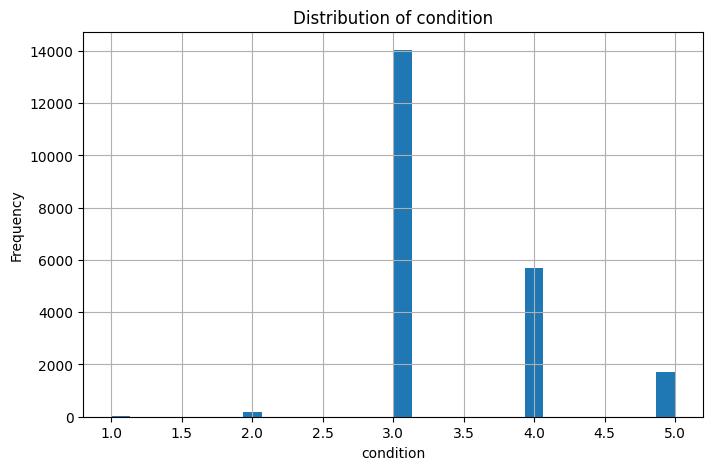

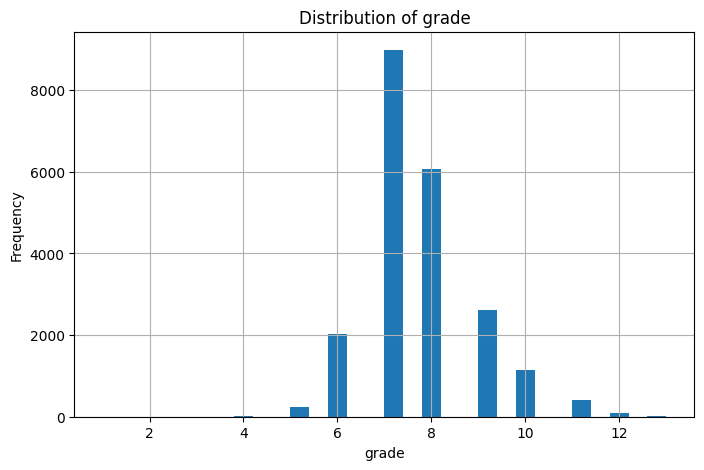

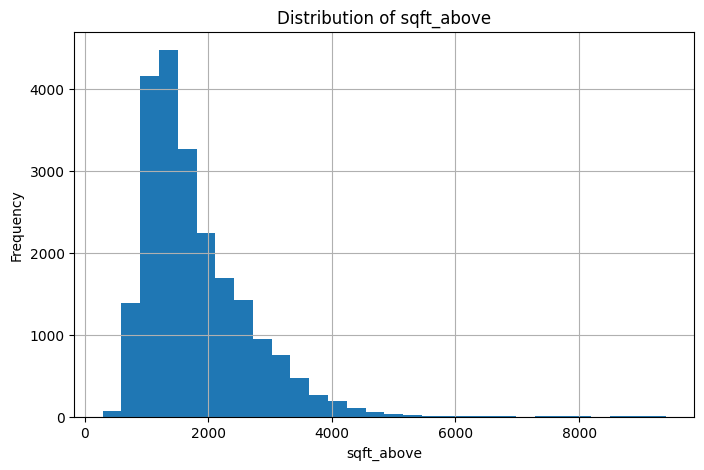

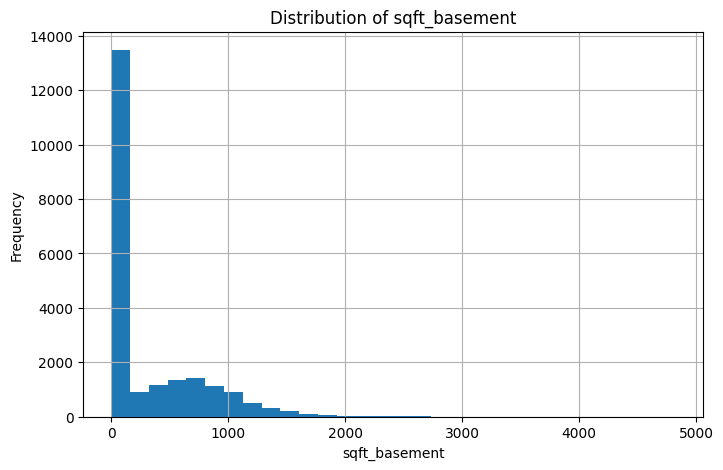

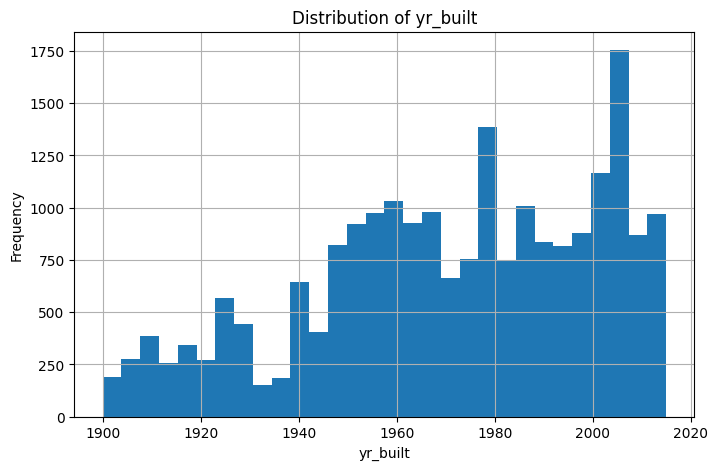

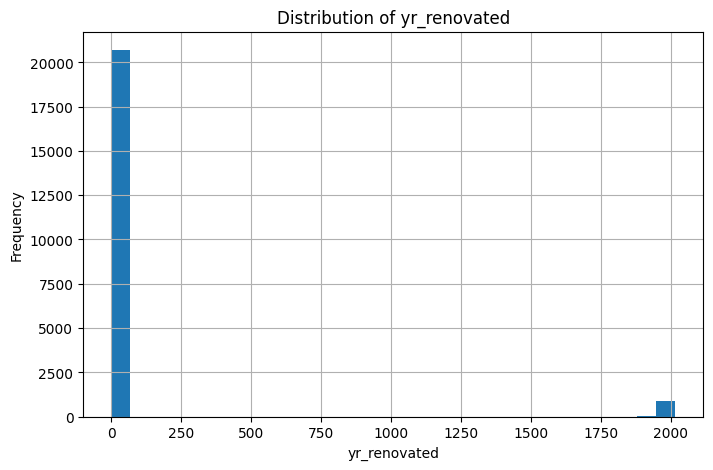

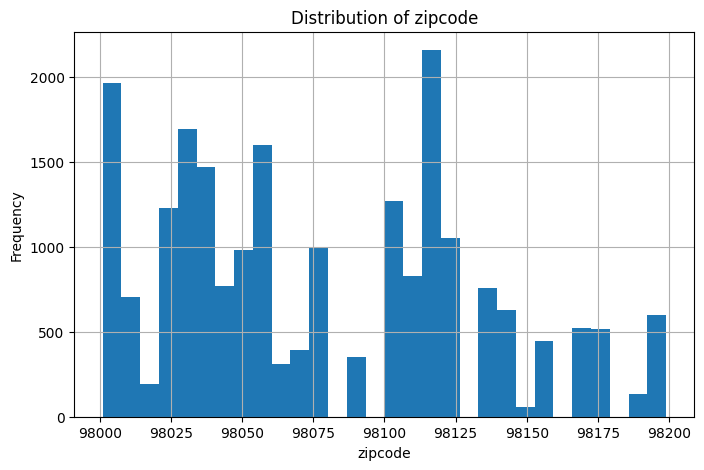

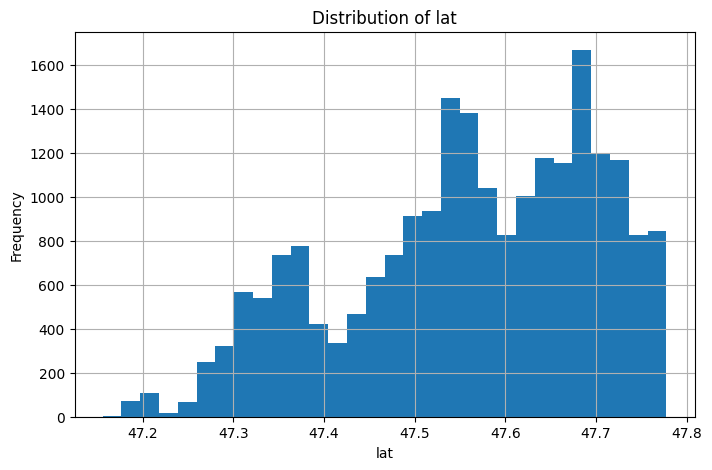

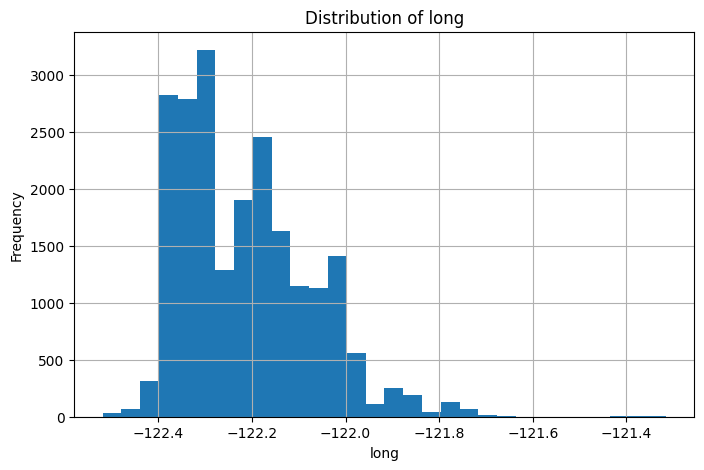

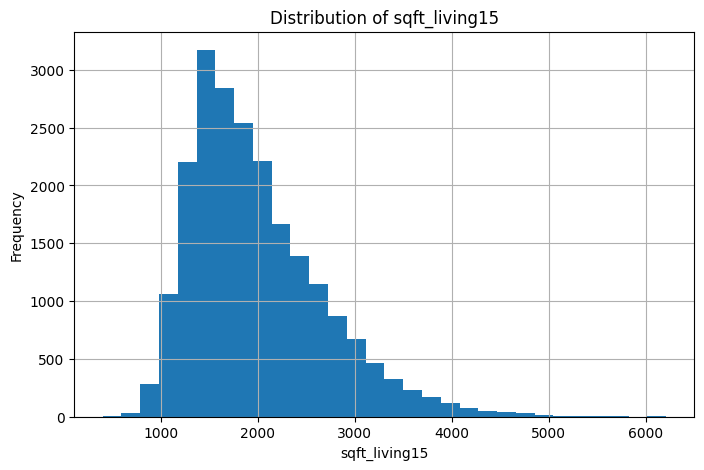

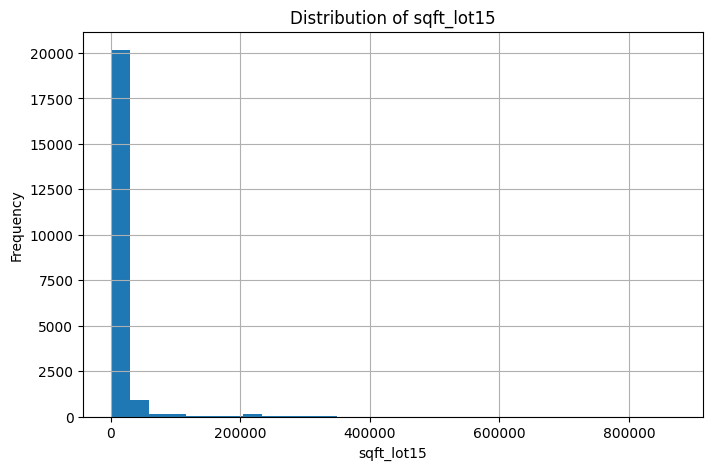

In [31]:
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    plt.hist(df[col], bins=30)

    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.grid(True)
    plt.show()

In [32]:
df.isnull().sum()

,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0
grade,0


## Sprint 1 Planning

### Sprint Goal

The main goal of Sprint 1 is to understand the car price dataset, complete the initial data preprocessing, and establish a baseline regression model that can be used for comparison with the neural network.

### Initial Backlog Tasks

1. **Dataset Selection and Understanding**
   - Load and inspect the car price dataset.
   - Identify numerical and categorical features.
   - Check for missing values and potential outliers.

2. **Data Preprocessing**
   - Handle missing values.
   - Encode categorical features.
   - Scale numerical features.
   - Split the data into training, validation, and test sets.

3. **Baseline Model**
   - Build a simple regression baseline using `DummyRegressor`.
   - Evaluate it using MAE, RMSE, and R².
   - Record the baseline results.

4. **Neural Network Baseline**
   - Build a Keras neural network for regression.
   - Train it using the training and validation sets.
   - Compare its performance with the baseline model.

### Acceptance Criteria

- The dataset is loaded and inspected successfully.
- Preprocessing is completed without data leakage.
- A baseline regression model is trained and evaluated.
- MAE, RMSE, and R² are recorded.
- The neural network can be trained and evaluated.
- All results are documented in the notebook.

In [33]:
# Drop ID, date, and target
X = df.drop(columns=['price'])
y = df['price']

# Numerical columns
numeric_cols = X.columns.tolist()

# Numerical pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols)
])

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Train shape:", X_train_processed.shape)
print("Validation shape:", X_val_processed.shape)
print("Test shape:", X_test_processed.shape)

Train shape: (12967, 18)
Validation shape: (4323, 18)
Test shape: (4323, 18)


### Baseline: LinearRegression

In [34]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Baseline model
baseline = DummyRegressor(strategy="mean")

# Train baseline
baseline.fit(X_train_processed, y_train)

# Predictions
baseline_pred = baseline.predict(X_test_processed)

# Evaluation
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline Results")
print("----------------")
print(f"MAE:  {baseline_mae:.4f}")
print(f"RMSE: {baseline_rmse:.4f}")
print(f"R²:   {baseline_r2:.4f}")

Baseline Results
----------------
MAE:  242663.5953
RMSE: 410080.4851
R²:   -0.0009


### Baseline Results

A `DummyRegressor` using the mean strategy was used as the baseline model.

The baseline achieved an MAE of **242,663.5953**, an RMSE of **410,080.4851**, and an R² score of **-0.0009**.

The baseline predicts the mean `price` for every observation, so it provides a simple reference point rather than a meaningful predictive model.

The neural network will be compared against this baseline. A successful neural network should achieve lower MAE and RMSE and a higher R² score.

The negative R² score indicates that the baseline performs slightly worse than simply using the mean as a reference, which is expected for a `DummyRegressor`.

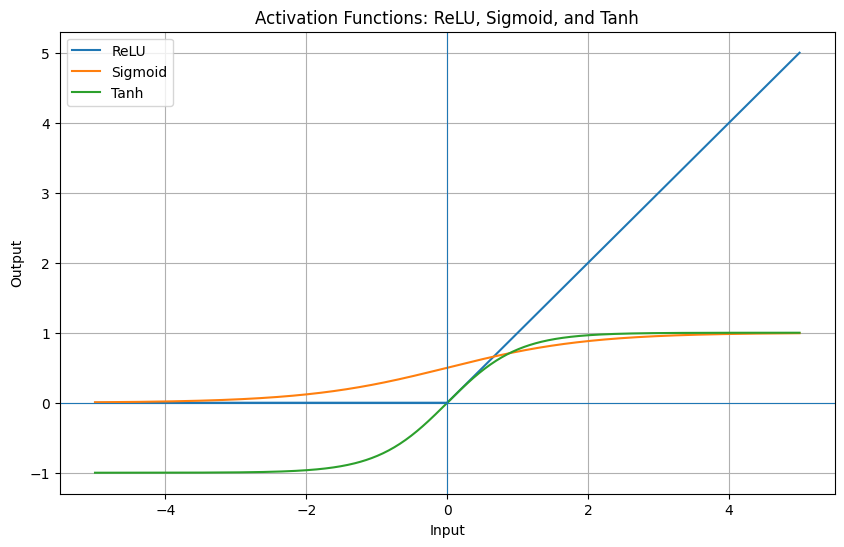

In [35]:
# Range of inputs
x = np.linspace(-5, 5, 500)

# Activation functions
relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)

# Plot
plt.figure(figsize=(10, 6))

plt.plot(x, relu, label='ReLU')
plt.plot(x, sigmoid, label='Sigmoid')
plt.plot(x, tanh, label='Tanh')

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Activation Functions: ReLU, Sigmoid, and Tanh')
plt.legend()
plt.grid(True)

plt.show()

### Activation Functions

The plot compares three commonly used activation functions: ReLU, Sigmoid, and Tanh.

- **ReLU:** Outputs 0 for negative inputs and keeps positive inputs unchanged. It is commonly used in hidden layers of neural networks.
- **Sigmoid:** Converts inputs into values between 0 and 1, making it suitable for binary classification output layers.
- **Tanh:** Converts inputs into values between -1 and 1 and is centered around zero.

For this project, **ReLU** is used in the hidden layers, while the final output layer for the regression task uses **no activation function** (`Dense(1)`).

### Output Activation and Loss Function

Since the Phase 3 project is a **regression task** where the goal is to predict a continuous house price, the output layer should use **no activation function**.

The final layer is:

`Dense(1)`

The single neuron produces a continuous numerical value representing the predicted house price. No activation is used because the model needs to be able to predict values across the full range of possible prices.

For the loss function, **Mean Squared Error (MSE)** is appropriate:

`loss="mse"`

MSE measures the average squared difference between the actual and predicted prices. Squaring the errors gives larger errors more weight, which encourages the neural network to reduce large prediction errors.

Therefore, the configuration is:

- **Task:** Regression
- **Output layer:** `Dense(1)`
- **Output activation:** None (linear)
- **Loss function:** Mean Squared Error (MSE)

This differs from binary classification, where a sigmoid activation and binary cross-entropy would be used. Since the target here is a continuous `price`, a linear output with MSE is the appropriate choice.

In [36]:
# Sample input
x = np.array([[2.0, 3.0]])

# Layer 1 weights and bias
W1 = np.array([
    [0.5, 0.2, 0.1],
    [0.4, 0.3, 0.6]
])

b1 = np.array([[0.1, 0.2, 0.3]])

# Layer 2 weights and bias
W2 = np.array([
    [0.7],
    [0.5],
    [0.2]
])

b2 = np.array([[0.1]])

# Forward pass - Layer 1
z1 = x @ W1 + b1
a1 = np.maximum(0, z1)  # ReLU

# Forward pass - Layer 2
z2 = a1 @ W2 + b2

# Final output
y_pred = z2

print("Layer 1 pre-activation:", z1)
print("Layer 1 activation:", a1)
print("Final output:", y_pred)

Layer 1 pre-activation: [[2.3 1.5 2.3]]
Layer 1 activation: [[2.3 1.5 2.3]]
Final output: [[2.92]]


### NumPy Forward Pass

A forward pass calculates the output of a neural network from an input without using a deep-learning framework.

The sample input is passed through two layers.

First, the weighted sum is calculated:

`z1 = x @ W1 + b1`

The ReLU activation is then applied:

`a1 = ReLU(z1)`

The activated values are passed to the second layer:

`z2 = a1 @ W2 + b2`

Since this example represents a regression network, the final output uses a **linear activation**, so the prediction is simply:

`y_pred = z2`

This demonstrates the basic process used by neural networks: **input → weighted sum → activation → next layer → prediction**.

### Four-Step Training Loop

**1. Forward Pass**  
Input → Neural Network → Prediction

⬇️

**2. Calculate Loss**  
Prediction ↔ Actual Value → Loss

⬇️

**3. Backpropagation**  
Loss → Calculate Gradients

⬇️

**4. Update Weights**  
Gradients + Adam → Updated Weights

⬇️

**Repeat for the next batch and epoch**

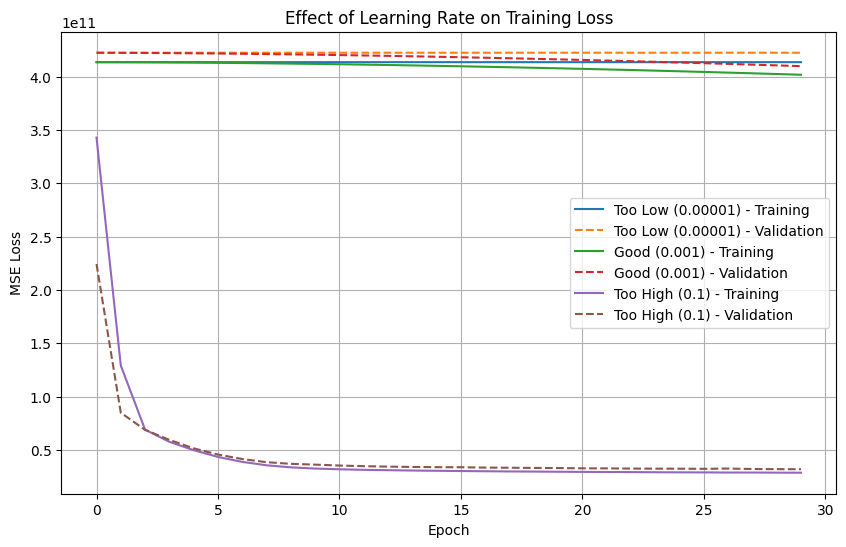

In [38]:
import tensorflow as tf

learning_rates = {
    "Too Low (0.00001)": 0.00001,
    "Good (0.001)": 0.001,
    "Too High (0.1)": 0.1
}

histories = {}

for name, lr in learning_rates.items():

    # Small network
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train_processed.shape[1],)),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1)
    ])

    # Compile with different learning rate
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="mse"
    )

    # Train
    history = model.fit(
        X_train_processed,
        y_train,
        validation_data=(X_val_processed, y_val),
        epochs=30,
        batch_size=32,
        verbose=0
    )

    histories[name] = history


# Plot loss curves
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        history.history["loss"],
        label=f"{name} - Training"
    )
    plt.plot(
        history.history["val_loss"],
        linestyle="--",
        label=f"{name} - Validation"
    )

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Effect of Learning Rate on Training Loss")
plt.legend()
plt.grid(True)
plt.show()

### Learning Rate Experiment

A small neural network was trained using three different learning rates while keeping the architecture, batch size, number of epochs, and data split fixed.

- **0.00001 (Too Low):** The loss decreases very slowly, indicating that the weight updates are too small for efficient learning.
- **0.001 (Good):** The loss decreases steadily and provides a good balance between learning speed and stability.
- **0.1 (High):** The loss decreases very quickly during the first few epochs and then levels off. In this experiment, it did not show severe instability, but the learning rate is relatively large and may be less reliable with different data or initializations.

Overall, the experiment shows that the learning rate strongly affects how quickly the neural network converges. The learning rate of **0.001** provides a stable learning behavior and is a reasonable choice for this project.

### Backpropagation and the Chain Rule

Backpropagation is the process used by a neural network to determine how much each weight and bias contributed to the prediction error.

After the forward pass, the model calculates the loss by comparing its prediction with the actual target. Backpropagation then works backward through the network and computes the **gradient of the loss with respect to each parameter**. These gradients tell the optimizer how the weights should be adjusted to reduce the loss.

The **chain rule** is involved because the output of one layer becomes the input to the next layer. Therefore, the loss depends on earlier weights indirectly through several intermediate calculations.

For example:

`Weight → Hidden Layer → Output → Loss`

To find how a weight affects the loss, the chain rule combines the derivatives through each step:

`dLoss/dWeight = dLoss/dOutput × dOutput/dHidden × dHidden/dWeight`

This allows the network to efficiently calculate gradients for all its parameters, which are then used by the optimizer, such as Adam, to update the weights.

In simple terms, **backpropagation works backward from the error to determine how each parameter should change, while the chain rule makes it possible to calculate these effects through multiple connected layers.**